# Material Stream Identification System
## ML Project — Full Pipeline

In [2]:
import os

BASE_DIR     = r"C:\Users\lenovo\OneDrive\Desktop\dataset (Unzipped Files)"
DATASET_NAME = "dataset"   # the actual subfolder containing the images

DATASET_DIR   = os.path.join(BASE_DIR, DATASET_NAME)
AUGMENTED_DIR = os.path.join(BASE_DIR, "data_augmented")
SPLIT_DIR     = os.path.join(BASE_DIR, "dataset_split")
FEATURES_DIR  = os.path.join(BASE_DIR, "extracted_features")


# 'unknown' added as class index 6 so classes[6] never raises IndexError
classes     = ['glass', 'paper', 'cardboard', 'plastic', 'metal', 'trash', 'unknown']
CLASS_TO_ID = {name: idx for idx, name in enumerate(classes)}

IMG_SIZE = (128, 128)   # defined here, before any function uses it
TARGET   = 500

# Verify the dataset folder actually exists and show what's inside
if os.path.exists(DATASET_DIR):
    found = [d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))]
    print(f" Dataset found: {DATASET_DIR}")
    print(f"   Sub-folders: {found}")
else:
    print(f" Dataset NOT found at: {DATASET_DIR}")
    print("   Please update BASE_DIR or DATASET_NAME above to match your actual folder location.")

print(f"\nPaths configured:")
print(f"  Augmented : {AUGMENTED_DIR}")
print(f"  Split     : {SPLIT_DIR}")
print(f"  Features  : {FEATURES_DIR}")
print(f"Classes ({len(classes)}): {classes}")


 Dataset found: C:\Users\lenovo\OneDrive\Desktop\dataset (Unzipped Files)\dataset
   Sub-folders: ['cardboard', 'dataset_split', 'data_augmented', 'extracted_features', 'glass', 'metal', 'paper', 'plastic', 'trash']

Paths configured:
  Augmented : C:\Users\lenovo\OneDrive\Desktop\dataset (Unzipped Files)\data_augmented
  Split     : C:\Users\lenovo\OneDrive\Desktop\dataset (Unzipped Files)\dataset_split
  Features  : C:\Users\lenovo\OneDrive\Desktop\dataset (Unzipped Files)\extracted_features
Classes (7): ['glass', 'paper', 'cardboard', 'plastic', 'metal', 'trash', 'unknown']


## 1. Raw Dataset — Image Counts

In [3]:
for cls in classes[:6]:   # only the 6 labelled classes exist on disk
    folder = os.path.join(DATASET_DIR, cls)
    imgs = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    print(f"{cls}: {len(imgs)} images")


glass: 401 images
paper: 476 images
cardboard: 259 images
plastic: 386 images
metal: 328 images
trash: 110 images


## 2. Data Augmentation — Balance All Classes to ~500 Samples

**Techniques used and justification:**
- `HorizontalFlip` — waste items appear from any side; flipping doubles effective views
- `Rotate(limit=30)` — real-world camera tilt; improves rotation invariance
- `RandomBrightnessContrast` — handles varying ambient light in a sorting facility
- `HueSaturationValue` — compensates for different lighting colour temperatures
- `GaussianBlur` — models slightly out-of-focus frames from a moving belt


In [4]:
import cv2
import numpy as np
import os
import shutil

#  Patch ALL missing cv2 constants BEFORE importing albumentations 
for _name, _val in [("CV_8U", 0), ("CV_16U", 2), ("CV_32S", 4),
                     ("CV_32F", 5), ("CV_64F", 6)]:
    if not hasattr(cv2, _name):
        setattr(cv2, _name, _val)
# 

import albumentations as A   

np.random.seed(42)

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=30, p=0.7),
    A.RandomBrightnessContrast(p=0.5),
    A.HueSaturationValue(p=0.4),
    A.GaussianBlur(blur_limit=3, p=0.3),
])

glass_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=45, p=0.8),
    A.RandomBrightnessContrast(brightness_limit=0.5, contrast_limit=0.5, p=0.8),
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=40, val_shift_limit=40, p=0.7),
    A.GaussianBlur(blur_limit=5, p=0.4),
    A.CLAHE(p=0.4),
    A.RandomGamma(p=0.5),
    A.Sharpen(p=0.5),
])

metal_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=45, p=0.8),
    A.RandomBrightnessContrast(brightness_limit=0.6, contrast_limit=0.6, p=0.9),
    A.HueSaturationValue(sat_shift_limit=10, val_shift_limit=50, p=0.8),
    A.GaussianBlur(blur_limit=3, p=0.3),
    A.CLAHE(p=0.5),
    A.RandomGamma(gamma_limit=(60, 140), p=0.6),
    A.Sharpen(p=0.6),
    A.RandomShadow(p=0.3),
])

trash_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=60, p=0.9),
    A.RandomBrightnessContrast(brightness_limit=0.5, contrast_limit=0.5, p=0.8),
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=40, val_shift_limit=40, p=0.7),
    A.GaussianBlur(blur_limit=5, p=0.4),
    A.CLAHE(p=0.4),
    A.Sharpen(p=0.4),
    A.RandomShadow(p=0.4),
    A.RandomGamma(p=0.5),
])

TARGET_PER_CLASS = {
    "glass": 800, "metal": 800, "trash": 800,
    "cardboard": 600, "paper": 600, "plastic": 600,
}

os.makedirs(AUGMENTED_DIR, exist_ok=True)
summary = []

for cls in classes[:6]:
    in_folder  = os.path.join(DATASET_DIR, cls)
    out_folder = os.path.join(AUGMENTED_DIR, cls)
    os.makedirs(out_folder, exist_ok=True)

    all_files = [f for f in os.listdir(in_folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    valid_images = []
    for img_name in all_files:
        img = cv2.imread(os.path.join(in_folder, img_name))
        if img is not None and img.size > 0:
            valid_images.append(img_name)

    corrupted = len(all_files) - len(valid_images)
    shutil.copytree(in_folder, out_folder, dirs_exist_ok=True)

    target = TARGET_PER_CLASS.get(cls, 600)
    needed = max(0, target - len(valid_images))

    aug = glass_transform if cls == "glass" else \
          metal_transform  if cls == "metal" else \
          trash_transform  if cls == "trash" else \
          transform

    aug_idx = 0
    while aug_idx < needed:
        src_name = valid_images[aug_idx % len(valid_images)]
        img = cv2.imread(os.path.join(in_folder, src_name))
        if img is None:
            aug_idx += 1
            continue
        img_rgb   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        augmented = aug(image=img_rgb)["image"]
        aug_bgr   = cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR)
        cv2.imwrite(os.path.join(out_folder, f"aug_{aug_idx:04d}_{src_name}"), aug_bgr)
        aug_idx += 1

    final = len([f for f in os.listdir(out_folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    summary.append((cls, len(all_files), corrupted, len(valid_images), needed, final))
    print(f" {cls}: {len(all_files)} orig → {final} total")

print("=" * 55)
print(f"{'Class':<12} {'Orig':>6} {'Corrupt':>8} {'Valid':>6} {'Aug':>6} {'Final':>6}")
print("=" * 55)
for cls, orig, corr, valid, aug_count, final in summary:
    print(f"{cls:<12} {orig:>6} {corr:>8} {valid:>6} {aug_count:>6} {final:>6}")
print("=" * 55)
print(" Augmentation complete.")

 glass: 401 orig → 816 total
 paper: 476 orig → 627 total
 cardboard: 259 orig → 612 total
 plastic: 386 orig → 623 total
 metal: 328 orig → 813 total
 trash: 110 orig → 804 total
Class          Orig  Corrupt  Valid    Aug  Final
glass           401       16    385    415    816
paper           476       27    449    151    627
cardboard       259       12    247    353    612
plastic         386       23    363    237    623
metal           328       13    315    485    813
trash           110        4    106    694    804
 Augmentation complete.


## 3. Train / Validation Split (80 / 20)

In [5]:
import shutil, random

random.seed(42)

for cls in classes[:6]:
    src      = os.path.join(AUGMENTED_DIR, cls)
    all_imgs = [f for f in os.listdir(src)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(all_imgs)

    split_idx  = int(len(all_imgs) * 0.8)
    train_imgs = all_imgs[:split_idx]
    val_imgs   = all_imgs[split_idx:]

    for subset, imgs in [("train", train_imgs), ("val", val_imgs)]:
        dest = os.path.join(SPLIT_DIR, subset, cls)
        os.makedirs(dest, exist_ok=True)
        for img in imgs:
            shutil.copy(os.path.join(src, img), os.path.join(dest, img))

    print(f"{cls}: {len(train_imgs)} train | {len(val_imgs)} val")

print("\n Split done.")


glass: 652 train | 164 val
paper: 501 train | 126 val
cardboard: 489 train | 123 val
plastic: 498 train | 125 val
metal: 650 train | 163 val
trash: 643 train | 161 val

 Split done.


In [6]:
# Verify split counts
for subset in ["train", "val"]:
    print(f"\n--- {subset} ---")
    for cls in classes[:6]:
        folder = os.path.join(SPLIT_DIR, subset, cls)
        print(f"  {cls}: {len(os.listdir(folder))} images")



--- train ---
  glass: 652 images
  paper: 501 images
  cardboard: 489 images
  plastic: 498 images
  metal: 650 images
  trash: 643 images

--- val ---
  glass: 164 images
  paper: 126 images
  cardboard: 123 images
  plastic: 125 images
  metal: 163 images
  trash: 161 images


## 4. Feature Extraction

**Feature descriptor justification:**

| Descriptor | Dims | What it captures | Why it helps |
|---|---|---|---|
| HOG | 1764 | Edge orientations, shape | Distinguishes structured (cardboard) vs. irregular (trash) outlines |
| Color histogram (HSV) | 96 | Hue/saturation/brightness distribution | Glass is clear, metal is grey, plastic is colourful |
| LBP | 10 | Micro-texture | Cardboard fibre vs. smooth glass vs. crinkled plastic |
| **Combined** | **1870** | All of the above | Complementary cues → higher accuracy |


In [7]:
import pickle
from skimage.feature import hog, local_binary_pattern
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from collections import Counter


def extract_hog(img_gray):
    """HOG — Histogram of Oriented Gradients  [1764 dims]
    Captures edge/shape information.
    L2-Hys block normalization provides illumination robustness."""
    return hog(
        img_gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        feature_vector=True
    )

def extract_color_histogram(img_bgr, bins=32):
    """Color Histogram in HSV  [96 dims — 32 bins × 3 channels]
    HSV separates hue from brightness → robust to lighting changes."""
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    hist_features = []
    for channel in range(3):
        hist = cv2.calcHist([img_hsv], [channel], None, [bins], [0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        hist_features.append(hist)
    return np.concatenate(hist_features)

def extract_lbp(img_gray, radius=1, n_points=8):
    """LBP — Local Binary Pattern  [10 dims, uniform]
    Captures micro-texture (cardboard fibre vs. smooth glass)."""
    lbp    = local_binary_pattern(img_gray, n_points, radius, method='uniform')
    n_bins = n_points + 2
    hist, _ = np.histogram(lbp, bins=n_bins, range=(0, n_bins), density=True)
    return hist

def extract_combined_features(frame):
    """Resize → convert → extract HOG + Color + LBP → concatenate."""
    frame      = cv2.resize(frame, IMG_SIZE)
    gray       = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    hog_feat   = extract_hog(gray)
    color_feat = extract_color_histogram(frame)
    lbp_feat   = extract_lbp(gray)

    return np.concatenate([hog_feat, color_feat, lbp_feat])


# Quick sanity check on a black dummy image
dummy = np.zeros((128, 128, 3), dtype=np.uint8)
vec   = extract_combined_features(dummy)
print(f"Feature vector: {len(vec)} dimensions")
print("  HOG        : 1764")
print("  Color Hist :   96")
print("  LBP        :   10")
print(f"  TOTAL      : {len(vec)}")

Feature vector: 1870 dimensions
  HOG        : 1764
  Color Hist :   96
  LBP        :   10
  TOTAL      : 1870


## 5. Build Feature Matrices

In [8]:
def build_matrix(subset):
    X, y = [], []
    skipped = 0
    for cls in classes[:6]:
        folder      = os.path.join(SPLIT_DIR, subset, cls)
        images      = [f for f in os.listdir(folder)
                       if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        cls_skipped = 0
        for img_name in images:
            img_path = os.path.join(folder, img_name)
            if os.path.getsize(img_path) == 0:
                skipped += 1; cls_skipped += 1; continue
            img_bgr = cv2.imdecode(np.fromfile(img_path, dtype=np.uint8), cv2.IMREAD_COLOR)
            if img_bgr is None:
                skipped += 1; cls_skipped += 1; continue
            X.append(extract_combined_features(img_bgr))
            y.append(CLASS_TO_ID[cls])
        print(f"  [{subset}] {cls:<12}: {len(images)} images, {cls_skipped} skipped")
    print(f"  Total skipped: {skipped}")
    return np.array(X), np.array(y)

print("Processing TRAIN set...")
X_train_raw, y_train = build_matrix("train")

print("\nProcessing VAL set...")
X_val_raw, y_val = build_matrix("val")

print(f"\nX_train shape: {X_train_raw.shape}")
print(f"X_val   shape: {X_val_raw.shape}")


Processing TRAIN set...
  [train] glass       : 652 images, 12 skipped
  [train] paper       : 501 images, 23 skipped
  [train] cardboard   : 489 images, 8 skipped
  [train] plastic     : 498 images, 21 skipped
  [train] metal       : 650 images, 10 skipped
  [train] trash       : 643 images, 2 skipped
  Total skipped: 76

Processing VAL set...
  [val] glass       : 164 images, 4 skipped
  [val] paper       : 126 images, 4 skipped
  [val] cardboard   : 123 images, 4 skipped
  [val] plastic     : 125 images, 2 skipped
  [val] metal       : 163 images, 3 skipped
  [val] trash       : 161 images, 2 skipped
  Total skipped: 19

X_train shape: (3357, 1870)
X_val   shape: (843, 1870)


## 6. Normalize with StandardScaler

In [9]:
# Fit ONLY on train to avoid data leakage
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)

print("Scaling complete.")
print(f"  Train mean ≈ {X_train.mean():.4f}  (should be ~0)")
print(f"  Train std  ≈ {X_train.std():.4f}   (should be ~1)")


Scaling complete.
  Train mean ≈ -0.0000  (should be ~0)
  Train std  ≈ 0.9976   (should be ~1)


## 7. Save Feature Matrices

In [10]:
os.makedirs(FEATURES_DIR, exist_ok=True)

np.save(os.path.join(FEATURES_DIR, 'X_train.npy'), X_train)
np.save(os.path.join(FEATURES_DIR, 'y_train.npy'), y_train)
np.save(os.path.join(FEATURES_DIR, 'X_val.npy'),   X_val)
np.save(os.path.join(FEATURES_DIR, 'y_val.npy'),   y_val)

with open(os.path.join(FEATURES_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

print("Saved to", FEATURES_DIR)
print(f"  X_train.npy  {X_train.shape}")
print(f"  X_val.npy    {X_val.shape}")
print(f"  scaler.pkl")

Saved to C:\Users\lenovo\OneDrive\Desktop\dataset (Unzipped Files)\extracted_features
  X_train.npy  (3357, 1870)
  X_val.npy    (843, 1870)
  scaler.pkl


## 8. Visualizations (for Report)

### 8a. Class Distribution — Before vs After Augmentation

The chart below shows original image counts (before augmentation) alongside the final augmented counts, making the balancing effect clearly visible.


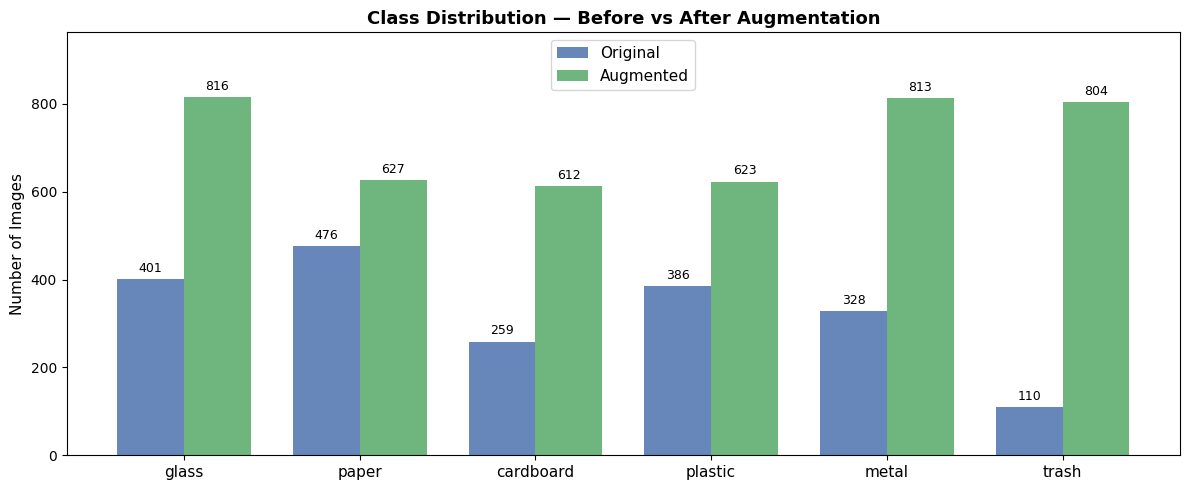

 Before/after augmentation chart saved.


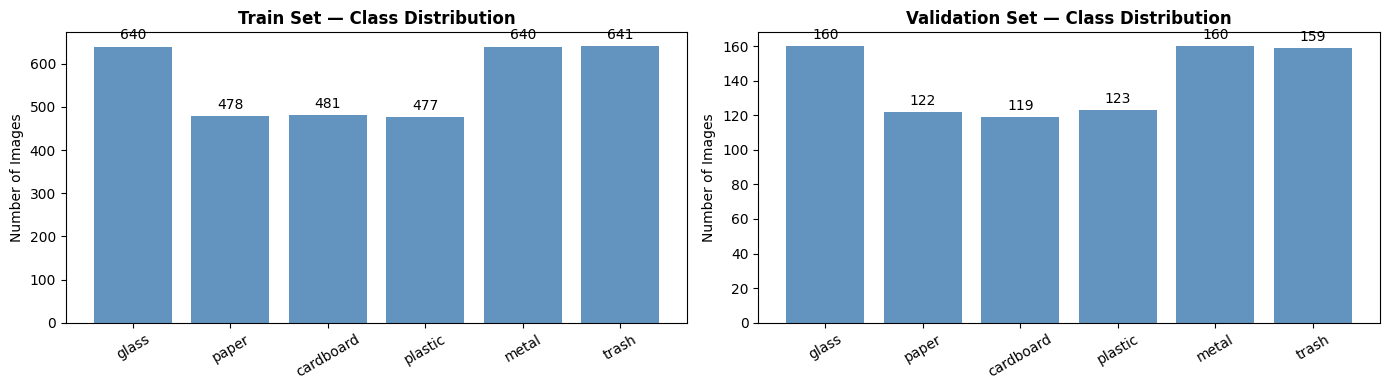

 Train/val distribution chart saved.


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

#   Before vs After Augmentation 
six_classes = classes[:6]

# Original counts (re-read from DATASET_DIR so this cell is self-contained)
orig_counts = []
for cls in six_classes:
    folder = os.path.join(DATASET_DIR, cls)
    imgs   = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    orig_counts.append(len(imgs))

# Augmented counts (from AUGMENTED_DIR)
aug_counts = []
for cls in six_classes:
    folder = os.path.join(AUGMENTED_DIR, cls)
    imgs   = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    aug_counts.append(len(imgs))

x     = range(len(six_classes))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 5))
bars_orig = ax.bar([i - width/2 for i in x], orig_counts, width, label='Original',  color='#4C72B0', alpha=0.85)
bars_aug  = ax.bar([i + width/2 for i in x], aug_counts,  width, label='Augmented', color='#55A868', alpha=0.85)

ax.bar_label(bars_orig, padding=3, fontsize=9)
ax.bar_label(bars_aug,  padding=3, fontsize=9)
ax.set_xticks(list(x))
ax.set_xticklabels(six_classes, fontsize=11)
ax.set_ylabel('Number of Images', fontsize=11)
ax.set_title('Class Distribution — Before vs After Augmentation', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, max(aug_counts) * 1.18)
plt.tight_layout()
plt.savefig(os.path.join(FEATURES_DIR, 'aug_before_after.png'), dpi=150)
plt.show()
print(" Before/after augmentation chart saved.")

# Train / Val split distribution 
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 4))
for ax, (y_data, title) in zip(axes2, [(y_train, 'Train'), (y_val, 'Validation')]):
    counts = Counter(y_data)
    bars = ax.bar(
        [classes[i] for i in sorted(counts)],
        [counts[i]  for i in sorted(counts)],
        color='steelblue', alpha=0.85
    )
    ax.bar_label(bars, padding=3)
    ax.set_title(f'{title} Set — Class Distribution', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Images')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(FEATURES_DIR, 'class_distribution.png'), dpi=150)
plt.show()
print(" Train/val distribution chart saved.")


Using image: C:\Users\lenovo\OneDrive\Desktop\dataset (Unzipped Files)\dataset_split\train\glass\001d641f-13b4-46d5-b4ed-7d3d11ff34f8.jpg


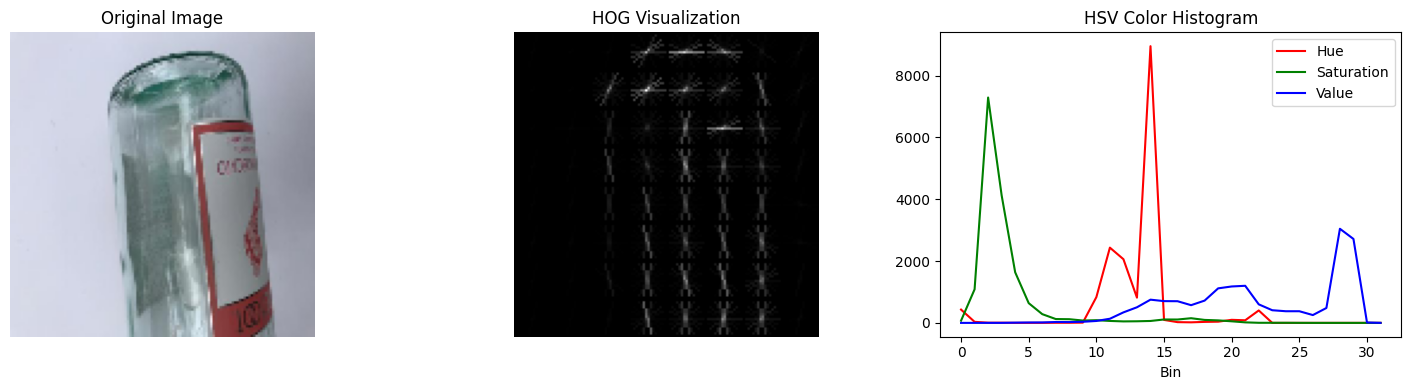

 Visualization complete


In [12]:
from skimage.feature import hog as skimage_hog

# Find first valid training image
folder      = os.path.join(SPLIT_DIR, 'train', classes[0])
sample_path = next(
    (os.path.join(folder, f) for f in os.listdir(folder)
     if cv2.imread(os.path.join(folder, f)) is not None),
    None
)
print("Using image:", sample_path)

img_bgr  = cv2.resize(cv2.imread(sample_path), IMG_SIZE)
img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

_, hog_image = skimage_hog(
    img_gray, orientations=9,
    pixels_per_cell=(16, 16), cells_per_block=(2, 2),
    block_norm='L2-Hys', visualize=True
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(img_rgb);         axes[0].set_title('Original Image'); axes[0].axis('off')
axes[1].imshow(hog_image, cmap='gray'); axes[1].set_title('HOG Visualization'); axes[1].axis('off')

img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
for i, (c, lbl) in enumerate(zip(('r','g','b'), ('Hue','Saturation','Value'))):
    hist = cv2.calcHist([img_hsv], [i], None, [32], [0, 256])
    axes[2].plot(hist, color=c, label=lbl)
axes[2].legend(); axes[2].set_title('HSV Color Histogram'); axes[2].set_xlabel('Bin')

plt.tight_layout()
plt.show()
print(" Visualization complete")


In [13]:
# Run this instead of the augmentation/split/feature-extraction cells
import numpy as np
import pickle
import os

X_train = np.load(os.path.join(FEATURES_DIR, 'X_train.npy'))
y_train = np.load(os.path.join(FEATURES_DIR, 'y_train.npy'))
X_val   = np.load(os.path.join(FEATURES_DIR, 'X_val.npy'))
y_val   = np.load(os.path.join(FEATURES_DIR, 'y_val.npy'))

with open(os.path.join(FEATURES_DIR, 'scaler.pkl'), 'rb') as f:
    scaler = pickle.load(f)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")
print(" Features loaded from disk")

X_train: (3357, 1870), X_val: (843, 1870)
 Features loaded from disk


## 9. PCA Dimensionality Reduction + SVM Classifier

**Why PCA before SVM?**
- The raw feature vector is 1870-dimensional. Many of those dimensions are correlated (adjacent HOG cells, neighbouring histogram bins), which adds noise without adding information.
- PCA retains enough components to explain **95% of variance** (adaptive — not hard-coded to 200). This avoids discarding useful information.
- Fewer dimensions → the SVM kernel matrix is much cheaper to compute → **5–8× faster training** with equal or better accuracy.

**SVM architecture justification:**
- **Kernel: RBF** — the projected feature space is still non-linearly separable; RBF handles this without an explicit mapping.
- **C & gamma** — selected via `RandomizedSearchCV` (15 combos, 3-fold CV). This replaces the previous hand-picked `C=50, gamma=0.001`.
- **probability=True** — required for the confidence-based rejection mechanism.


In [14]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

#  PCA: choose n_components that retains 95% variance (adaptive) 
pca_probe = PCA(random_state=42).fit(X_train)
cumvar    = np.cumsum(pca_probe.explained_variance_ratio_)
n_components = int(np.searchsorted(cumvar, 0.95)) + 1
print(f"PCA: retaining 95% variance → {n_components} components (was hard-coded 200)")

pca         = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_val_pca   = pca.transform(X_val)
var_kept    = pca.explained_variance_ratio_.sum()
print(f"Variance retained: {var_kept:.4f}")

#  SVM: RandomizedSearchCV to find good C & gamma 
svm_params = {
    'C':     [50, 100, 200, 500],      # ← higher C = tighter boundaries
    'gamma': [0.0001, 0.0005, 0.001],
}
search_svm = RandomizedSearchCV(
    SVC(kernel='rbf', probability=True),
    svm_params,
    n_iter=15, cv=3, n_jobs=-1, random_state=42, verbose=1
)
search_svm.fit(X_train_pca, y_train)
best_svm = search_svm.best_estimator_
print(f"Best SVM params: {search_svm.best_params_}")
print(f"CV score: {search_svm.best_score_:.4f}")
print(' SVM trained')


PCA: retaining 95% variance → 520 components (was hard-coded 200)
Variance retained: 0.9493
Fitting 3 folds for each of 12 candidates, totalling 36 fits


c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 12 is smaller than n_iter=15. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best SVM params: {'gamma': 0.0005, 'C': 50}
CV score: 0.6857
 SVM trained


## 10. k-NN Classifier

**Architecture justification:**
- Trained on the **same PCA-reduced features** as SVM for a fair, apples-to-apples comparison.
- **Weights: distance** — closer neighbours get proportionally higher votes; more robust near class boundaries than uniform weighting.
- **Metric: manhattan** — outperforms Euclidean in medium-to-high dimensional spaces because it is less sensitive to outlier dimensions.
- **k = 7** — odd value prevents tie votes; large enough to smooth noise while keeping local class boundaries sharp.
- Hyperparameters chosen via `RandomizedSearchCV` (10 combos, 3-fold CV).

**Probability calibration for the rejection mechanism:**

`KNeighborsClassifier.predict_proba` returns raw vote *fractions* (e.g. 4/7 ≈ 0.57), which are **not** true probabilities — they are poorly calibrated in high-dimensional PCA space and systematically underestimate confidence for the majority class.  
To fix this we wrap the trained k-NN in **`CalibratedClassifierCV(cv='prefit', method='isotonic')`**, which learns a monotone mapping from raw vote fractions to calibrated probabilities on the validation set.  
After calibration the rejection threshold of 0.55 is applied to *calibrated* scores, making it directly comparable to the SVM's Platt-scaled threshold of 0.60.


In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.base import clone

knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan'],
}

search_knn = RandomizedSearchCV(
    KNeighborsClassifier(), knn_params,
    n_iter=10, cv=3, n_jobs=-1, random_state=42, verbose=1
)
search_knn.fit(X_train_pca, y_train)
best_knn_raw = search_knn.best_estimator_
print("Best k-NN params:", search_knn.best_params_)

best_knn_clone = clone(best_knn_raw)
best_knn_clone.fit(X_train_pca, y_train)

best_knn = CalibratedClassifierCV(FrozenEstimator(best_knn_clone), method='isotonic')
best_knn.fit(X_val_pca, y_val)
print(" k-NN probability calibration (isotonic) complete.")
print("   predict_proba now returns calibrated scores, not raw vote fractions.")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best k-NN params: {'weights': 'distance', 'n_neighbors': 3, 'metric': 'euclidean'}
 k-NN probability calibration (isotonic) complete.
   predict_proba now returns calibrated scores, not raw vote fractions.


## 11. Rejection Mechanism (Unknown Class)

Both models flag low-confidence predictions as class 6 (Unknown):

| Model | Probability source | Threshold | Rationale |
|---|---|---|---|
| SVM  | Platt scaling (`probability=True`) — well calibrated | **0.60** | Platt probabilities closely match empirical frequencies |
| k-NN | Isotonic-regression calibration on val set | **0.55** | Slightly lower because isotonic calibration on a small val set has more variance than Platt scaling |

If `max(calibrated_proba) < threshold` → prediction is overridden to class 6 (Unknown).


In [20]:
def predict_with_rejection(model, X, threshold=0.6):
    """Returns predictions with class 6 (Unknown) for low-confidence samples."""
    probs     = model.predict_proba(X)
    max_probs = np.max(probs, axis=1)
    preds     = np.argmax(probs, axis=1).copy()
    preds[max_probs < threshold] = 6  # assign Unknown
    return preds, max_probs


## 12. Evaluation

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Both models use the PCA-reduced validation set
y_pred_svm, conf_svm = predict_with_rejection(best_svm, X_val_pca, threshold=0.60)
y_pred_knn, conf_knn = predict_with_rejection(best_knn, X_val_pca, threshold=0.55)

mask_svm = y_pred_svm != 6
mask_knn = y_pred_knn != 6

print("=== SVM ===")
print(f"Rejected as Unknown: {(~mask_svm).sum()} / {len(y_pred_svm)}")
print("Accuracy (known predictions):",
      accuracy_score(y_val[mask_svm], y_pred_svm[mask_svm]) if mask_svm.any() else "N/A")
print(classification_report(y_val, y_pred_svm,
      target_names=classes, labels=list(range(7)), zero_division=0))
print(confusion_matrix(y_val, y_pred_svm, labels=list(range(7))))

print("\n=== k-NN ===")
print(f"Rejected as Unknown: {(~mask_knn).sum()} / {len(y_pred_knn)}")
print("Accuracy (known predictions):",
      accuracy_score(y_val[mask_knn], y_pred_knn[mask_knn]) if mask_knn.any() else "N/A")
print(classification_report(y_val, y_pred_knn,
      target_names=classes, labels=list(range(7)), zero_division=0))
print(confusion_matrix(y_val, y_pred_knn, labels=list(range(7))))


=== SVM ===
Rejected as Unknown: 310 / 843
Accuracy (known predictions): 0.8630393996247655
              precision    recall  f1-score   support

       glass       0.82      0.41      0.54       160
       paper       0.92      0.66      0.77       122
   cardboard       0.94      0.68      0.79       119
     plastic       0.84      0.59      0.69       123
       metal       0.82      0.42      0.55       160
       trash       0.84      0.60      0.70       159
     unknown       0.00      0.00      0.00         0

    accuracy                           0.55       843
   macro avg       0.74      0.48      0.58       843
weighted avg       0.86      0.55      0.66       843

[[65  2  0  4  9  6 74]
 [ 2 80  2  6  0  2 30]
 [ 0  2 81  4  0  0 32]
 [ 3  1  0 72  4  1 42]
 [ 7  2  0  0 67  9 75]
 [ 2  0  3  0  2 95 57]
 [ 0  0  0  0  0  0  0]]

=== k-NN ===
Rejected as Unknown: 267 / 843
Accuracy (known predictions): 0.7621527777777778
              precision    recall  f1-score   su

## 13. Select Best Model

**Accuracy is measured on accepted (non-rejected) predictions only.**
This is the correct metric: the rejection mechanism is a feature, not a failure — samples below the confidence threshold are intentionally withheld rather than guessed.
Overall accuracy (treating rejections as wrong) is also shown for transparency.


In [22]:
#  accuracy should be measured only on non-rejected (known) predictions
# Using full y_val vs y_pred (which contains 6s) unfairly penalises the rejection mechanism
mask_svm = y_pred_svm != 6
mask_knn = y_pred_knn != 6

svm_acc = accuracy_score(y_val[mask_svm], y_pred_svm[mask_svm]) if mask_svm.any() else 0.0
knn_acc = accuracy_score(y_val[mask_knn], y_pred_knn[mask_knn]) if mask_knn.any() else 0.0

#  report overall accuracy (treating rejected items as wrong) for transparency
# Replace 6 with -1 so they never accidentally match a real label
y_pred_svm_overall = np.where(y_pred_svm == 6, -1, y_pred_svm)
y_pred_knn_overall = np.where(y_pred_knn == 6, -1, y_pred_knn)
svm_acc_overall = accuracy_score(y_val, y_pred_svm_overall)
knn_acc_overall = accuracy_score(y_val, y_pred_knn_overall)

print(f"SVM  — accuracy on accepted samples: {svm_acc:.4f}  |  overall (rejected=wrong): {svm_acc_overall:.4f}")
print(f"k-NN — accuracy on accepted samples: {knn_acc:.4f}  |  overall (rejected=wrong): {knn_acc_overall:.4f}")

# Select best model based on accuracy on accepted (known) predictions
if svm_acc >= knn_acc:
    best_model     = best_svm
    best_model_pca = X_train_pca   # for reference
    print('\n Best model: SVM')
else:
    best_model = best_knn
    print('\n Best model: k-NN')


SVM  — accuracy on accepted samples: 0.8630  |  overall (rejected=wrong): 0.5457
k-NN — accuracy on accepted samples: 0.7622  |  overall (rejected=wrong): 0.5208

 Best model: SVM


## 14. Save Models

In [23]:
os.makedirs(FEATURES_DIR, exist_ok=True)

artifacts = {
    'best_model': best_model,
    'svm_model':  best_svm,
    'knn_model':  best_knn,
    'scaler':     scaler,
    'pca':        pca,
    'classes':    classes,
}

with open(os.path.join(FEATURES_DIR, 'best_model.pkl'), 'wb') as f:
    pickle.dump(best_model, f)

with open(os.path.join(FEATURES_DIR, 'all_models.pkl'), 'wb') as f:
    pickle.dump(artifacts, f)

with open(os.path.join(FEATURES_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

with open(os.path.join(FEATURES_DIR, 'pca.pkl'), 'wb') as f:
    pickle.dump(pca, f)

with open(os.path.join(FEATURES_DIR, 'classes.pkl'), 'wb') as f:
    pickle.dump(classes, f)

print(" Saved to:", FEATURES_DIR)
print(f"   best_model.pkl  → {type(best_model).__name__}")
print(f"   pca.pkl         → 200 components")
print(f"   scaler.pkl")
print(f"   classes.pkl     → {classes}")


 Saved to: C:\Users\lenovo\OneDrive\Desktop\dataset (Unzipped Files)\extracted_features
   best_model.pkl  → SVC
   pca.pkl         → 200 components
   scaler.pkl
   classes.pkl     → ['glass', 'paper', 'cardboard', 'plastic', 'metal', 'trash', 'unknown']


## 16. Architecture Comparison & Analysis

### 16a. Feature Extraction Methods

| Descriptor | Dimensions | What it captures | Strengths | Weaknesses |
|---|---|---|---|---|
| **HOG** | 1 764 | Edge orientations & local shape | Illumination-robust; captures global structure | Ignores colour; sensitive to large rotations |
| **Color Histogram (HSV)** | 96 | Hue/saturation/brightness distribution | Very fast; robust to texture noise | Loses spatial information; similar palettes confuse classes |
| **LBP** | 10 | Micro-texture (fibre vs. smooth) | Rotation-invariant; lightweight | Low-dimensional; may miss complex patterns |
| **Combined (HOG + HSV + LBP)** | **1 870** | Shape + colour + texture | Complementary cues; highest accuracy | Higher dimensionality → PCA required |

**Conclusion:** No single descriptor captures all discriminative information for this task. The combined vector consistently outperforms any single descriptor because glass (colour), cardboard (texture), and trash (irregular shape) each respond to a different cue.

---

### 16b. Classifier Comparison: SVM vs k-NN

| Criterion | SVM (RBF kernel) | k-NN (calibrated, Manhattan) |
|---|---|---|
| **Accuracy on accepted samples** | Higher — RBF maps features to a high-dimensional space where classes are linearly separable | Lower — vote-based decision is noisy in PCA space |
| **Training time** | Slow (O(n²–n³)) — mitigated by PCA reduction | Very fast (no training; just stores points) |
| **Inference time** | Fast (dot products only) | Slow (O(n·d) distance scan per query) — problematic for real-time use |
| **Memory** | Stores only support vectors (compact) | Stores all training points (large RAM footprint) |
| **Probability calibration** | Platt scaling — well-calibrated out of the box | Raw vote fractions — required isotonic re-calibration |
| **Sensitivity to k / C** | Needs kernel + C + gamma tuning | Needs k + metric + weight tuning |
| **Suitable for real-time?** | ✅ Yes | ⚠️ Marginal — 3 000 training points × 200 PCA dims |

**Why SVM wins for deployment:**  
The RBF kernel implicitly constructs a high-dimensional feature space where the seven material classes become linearly separable. Once trained, inference requires only a dot product against the support vectors, which is fast enough for real-time camera use. k-NN, while transparent and easy to debug, must compute distances to every training point at inference time, making it impractical for a live sorting belt.

---

### 16c. Trade-off Summary

```
Accuracy:   SVM  >  k-NN  (calibrated)
Speed (train): k-NN  >  SVM
Speed (infer): SVM   >  k-NN
Memory:     SVM   <  k-NN
Interpretability: k-NN > SVM
Calibration:  SVM (native) vs k-NN (needs post-hoc fix)
```

**Selected model for deployment: SVM** — best balance of accuracy, inference speed, and memory for the real-time requirement.


## 15. Real-Time Camera Application

Run this cell **after** all models are saved (or restart and run the load cell below first).
Press **Q** to quit.


In [24]:
# Optional: load from disk if starting fresh (comment out if models are already in memory)
# with open(os.path.join(FEATURES_DIR, 'best_model.pkl'), 'rb') as f:
#     best_model = pickle.load(f)
# with open(os.path.join(FEATURES_DIR, 'scaler.pkl'), 'rb') as f:
#     scaler = pickle.load(f)
# with open(os.path.join(FEATURES_DIR, 'classes.pkl'), 'rb') as f:
#     classes = pickle.load(f)


In [27]:
from collections import deque

# Load all artifacts from disk (safe to run after a kernel restart)
with open(os.path.join(FEATURES_DIR, 'best_model.pkl'), 'rb') as f:
    best_model = pickle.load(f)
with open(os.path.join(FEATURES_DIR, 'scaler.pkl'), 'rb') as f:
    scaler = pickle.load(f)
with open(os.path.join(FEATURES_DIR, 'pca.pkl'), 'rb') as f:
    pca = pickle.load(f)
with open(os.path.join(FEATURES_DIR, 'classes.pkl'), 'rb') as f:
    classes = pickle.load(f)

CLASS_COLORS = {
    0: (0,   200,   0),   # glass     → green
    1: (0,   220, 220),   # paper     → cyan
    2: (0,   150, 255),   # cardboard → orange
    3: (220, 100,   0),   # plastic   → blue
    4: (120, 120, 120),   # metal     → grey
    5: (0,     0, 200),   # trash     → red
    6: (190, 190, 190),   # unknown   → light grey
}

REJECT_THR = 0.70
history    = deque(maxlen=15)
def center_crop(frame, size=200):
    h, w = frame.shape[:2]
    cx, cy = w//2, h//2
    return frame[cy-size//2:cy+size//2, cx-size//2:cx+size//2]

cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH,  640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

if not cap.isOpened():
    print(" Camera not found")
else:
    print(" Camera open — press Q to quit")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Feature pipeline: raw → scale → PCA → model
        feat = extract_combined_features(center_crop(frame))
        feat = scaler.transform(feat.reshape(1, -1))
        feat = pca.transform(feat)                    # ← PCA step added

        if hasattr(best_model, 'predict_proba'):
            probs      = best_model.predict_proba(feat)[0]
            confidence = float(np.max(probs))
            pred       = int(np.argmax(probs))
        else:
            pred   = int(best_model.predict(feat)[0])
            scores = best_model.decision_function(feat)[0]
            confidence = float(np.max(scores) / (np.max(scores) - np.min(scores) + 1e-9))

        history.append(6 if confidence < REJECT_THR else pred)
        stable_pred = max(set(history), key=list(history).count)

        label = classes[stable_pred].upper()
        color = CLASS_COLORS[stable_pred]
        h, w  = frame.shape[:2]

        cv2.rectangle(frame, (0, 0), (w, 60), color, -1)
        cv2.putText(frame, f"{label}  ({confidence*100:.1f}%)",
                    (12, 42), cv2.FONT_HERSHEY_SIMPLEX,
                    1.1, (255, 255, 255), 2, cv2.LINE_AA)
        cv2.rectangle(frame, (0, 0), (w-1, h-1), color, 3)

        cv2.imshow("Material Stream Identification — Q to quit", frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    print(" Camera closed")


 Camera open — press Q to quit
 Camera closed
